# <center>Introduction to Pandas</center>

![](https://pandas.pydata.org/_static/pandas_logo.png)


## Installation

Simply,
```
pip install pandas
```


## Reading data from a CSV file

You can read data from a CSV file using the ``read_csv`` function. By default, it assumes that the fields are comma-separated.

In [14]:
# import pandasi
import pandas as pd


>The `imdb.csv` dataset contains Highest Rated IMDb "Top 1000" Titles.

In [15]:
# load imdb dataset as pandas dataframe

data = pd.read_csv("imdb_1000.csv")
print(data)

     star_rating                                            title  \
0            9.3                         The Shawshank Redemption   
1            9.2                                    The Godfather   
2            9.1                           The Godfather: Part II   
3            9.0                                  The Dark Knight   
4            8.9                                     Pulp Fiction   
..           ...                                              ...   
974          7.4                                          Tootsie   
975          7.4                      Back to the Future Part III   
976          7.4  Master and Commander: The Far Side of the World   
977          7.4                                      Poltergeist   
978          7.4                                      Wall Street   

    content_rating      genre  duration  \
0                R      Crime       142   
1                R      Crime       175   
2                R      Crime       200   

In [20]:
# show first 5 rows of imdb_df
print(data.head(5))


   star_rating                     title content_rating   genre  duration  \
0          9.3  The Shawshank Redemption              R   Crime       142   
1          9.2             The Godfather              R   Crime       175   
2          9.1    The Godfather: Part II              R   Crime       200   
3          9.0           The Dark Knight          PG-13  Action       152   
4          8.9              Pulp Fiction              R   Crime       154   

                                         actors_list  
0  [u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...  
1    [u'Marlon Brando', u'Al Pacino', u'James Caan']  
2  [u'Al Pacino', u'Robert De Niro', u'Robert Duv...  
3  [u'Christian Bale', u'Heath Ledger', u'Aaron E...  
4  [u'John Travolta', u'Uma Thurman', u'Samuel L....  


>The `bikes.csv` dataset contains information about the number of bicycles that used certain bicycle lanes in Montreal in the year 2012.

In [22]:
# load bikes dataset as pandas dataframe
bikes_df = pd.read_csv("bikes.csv")
print(bikes_df)

    Date;;Rachel / Papineau;Berri1;Maisonneuve_2;Maisonneuve_1;Brébeuf;Parc;PierDup;CSC (Côte Sainte-Catherine);Pont_Jacques_Cartier
0            01/01/2012;00:00;16;35;51;38;5;26;10;0;27                                                                              
1           02/01/2012;00:00;43;83;153;68;11;53;6;1;21                                                                              
2          03/01/2012;00:00;58;135;248;104;2;89;3;2;15                                                                              
3         04/01/2012;00:00;61;144;318;116;2;111;8;1;19                                                                              
4         05/01/2012;00:00;95;197;330;124;6;97;13;2;16                                                                              
..                                                 ...                                                                              
361                  27/12/2012;00:00;8;12;7;4;;1;2;0;               

In [23]:
# show first 3 rows of bikes_df
print(bikes_df.head(3))

  Date;;Rachel / Papineau;Berri1;Maisonneuve_2;Maisonneuve_1;Brébeuf;Parc;PierDup;CSC (Côte Sainte-Catherine);Pont_Jacques_Cartier
0          01/01/2012;00:00;16;35;51;38;5;26;10;0;27                                                                              
1         02/01/2012;00:00;43;83;153;68;11;53;6;1;21                                                                              
2        03/01/2012;00:00;58;135;248;104;2;89;3;2;15                                                                              


## Selecting columns

When you read a CSV, you get a kind of object called a DataFrame, which is made up of rows and columns. You get columns out of a DataFrame the same way you get elements out of a dictionary.

In [24]:
# list columns of imdb_df
data.columns

Index(['star_rating', 'title', 'content_rating', 'genre', 'duration',
       'actors_list'],
      dtype='object')

In [25]:
# what are the datatypes of values in columns
data.dtypes

star_rating       float64
title              object
content_rating     object
genre              object
duration            int64
actors_list        object
dtype: object

In [26]:
# list first 5 movie titles
data['title'].head(5)

0    The Shawshank Redemption
1               The Godfather
2      The Godfather: Part II
3             The Dark Knight
4                Pulp Fiction
Name: title, dtype: object

In [29]:
# show only movie title and genre
data[['title','genre']].head(5)

,title,genre
0,The Shawshank Redemption,Crime
1,The Godfather,Crime
2,The Godfather: Part II,Crime
3,The Dark Knight,Action
4,Pulp Fiction,Crime


## Understanding columns

On the inside, the type of a column is ``pd.Series`` and pandas Series are internally numpy arrays. If you add ``.values`` to the end of any Series, you'll get its internal **numpy array**.

In [30]:
# show the type of duration column
type(data['duration'])

pandas.core.series.Series

In [31]:
# show duration values of movies as numpy arrays
type(data['duration'].values)

numpy.ndarray

## Applying functions to columns

Use `.apply` function to apply any function to each element of a column.

In [34]:
# convert all the movie titles to uppercase
data['title'] = data['title'].str.upper()
data['title'].head()

0    THE SHAWSHANK REDEMPTION
1               THE GODFATHER
2      THE GODFATHER: PART II
3             THE DARK KNIGHT
4                PULP FICTION
Name: title, dtype: object

## Plotting a column

Use ``.plot()`` function!

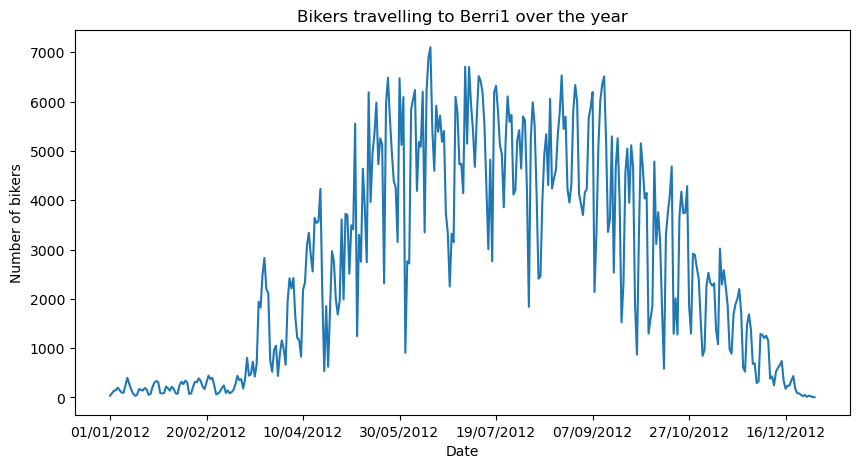

In [41]:
# plot the bikers travelling to Berri1 over the year

bikes = pd.read_csv("bikes.csv")
bikes.columns

bikes = pd.read_csv("bikes.csv", sep=';', parse_dates=['Date'], index_col='Date')

import matplotlib.pyplot as plt

bikes['Berri1'].plot(figsize=(10,5))
plt.title("Bikers travelling to Berri1 over the year")
plt.xlabel("Date")
plt.ylabel("Number of bikers")
plt.show()

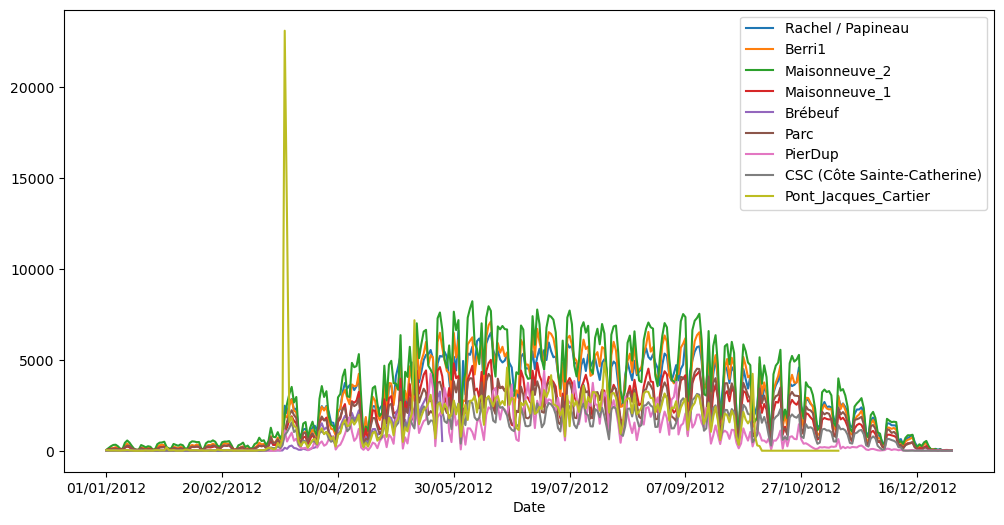

['Unnamed: 1', 'Rachel / Papineau', 'Berri1', 'Maisonneuve_2', 'Maisonneuve_1', 'Brébeuf', 'Parc', 'PierDup', 'CSC (Côte Sainte-Catherine)', 'Pont_Jacques_Cartier']


In [48]:
# plot all the columns of bikes_df

bikes_df = pd.read_csv("bikes.csv", sep=';', parse_dates=['Date'], index_col='Date')

bikes_df.dtypes

bikes_df.plot(figsize=(12,6))
plt.show()

print(bikes_df.columns.tolist())

## Value counts

Get count of unique values in a particular column/Series.

In [49]:
# what are the unique genre in imdb_df?
data['genre'].unique()

array(['Crime', 'Action', 'Drama', 'Western', 'Adventure', 'Biography',
       'Comedy', 'Animation', 'Mystery', 'Horror', 'Film-Noir', 'Sci-Fi',
       'History', 'Thriller', 'Family', 'Fantasy'], dtype=object)

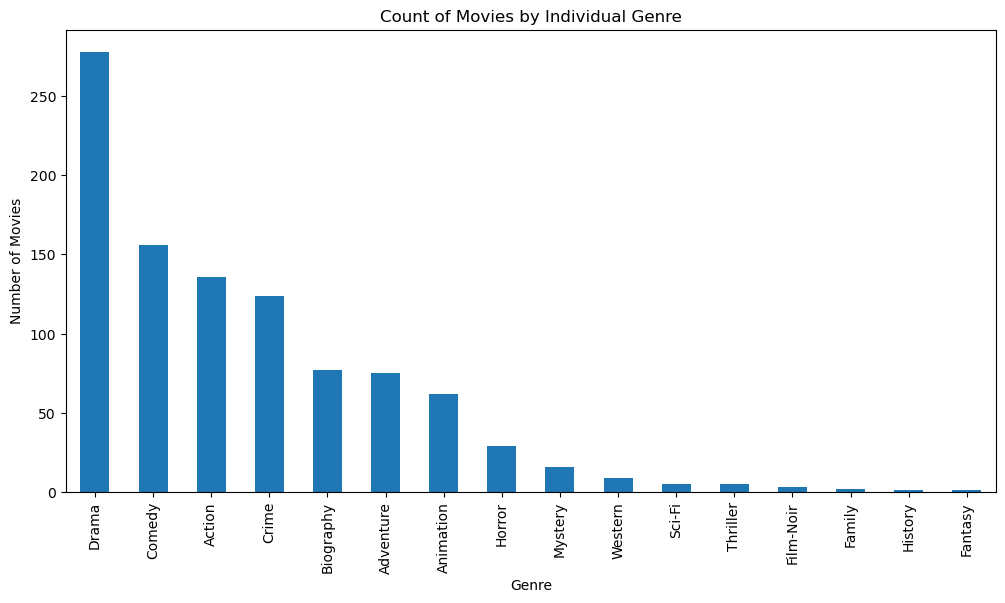

In [52]:
# plotting value counts of unique genres as a bar chart

data['genre'].str.split('|').explode().value_counts().plot(kind='bar', figsize=(12,6))

plt.title("Count of Movies by Individual Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.show()

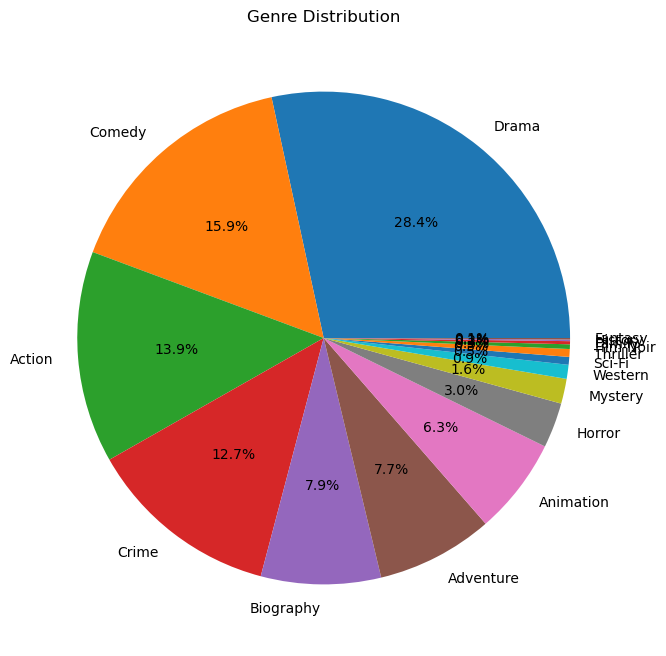

In [53]:
# plotting value counts of unique genres as a pie chart

data['genre'].value_counts().plot(
    kind='pie',
    figsize=(8,8),
    autopct='%1.1f%%'
)

plt.title("Genre Distribution")
plt.ylabel("")  
plt.show()

## Index

### DATAFRAME = COLUMNS + INDEX + ND DATA

### SERIES = INDEX + 1-D DATA

**Index** or (**row labels**) is one of the fundamental data structure of pandas. It can be thought of as an **immutable array** and an **ordered set**.

> Every row is uniquely identified by its index value.

In [54]:
# show index of bikes_df
bikes_df.index

Index(['01/01/2012', '02/01/2012', '03/01/2012', '04/01/2012', '05/01/2012',
       '06/01/2012', '07/01/2012', '08/01/2012', '09/01/2012', '10/01/2012',
       ...
       '22/12/2012', '23/12/2012', '24/12/2012', '25/12/2012', '26/12/2012',
       '27/12/2012', '28/12/2012', '29/12/2012', '30/12/2012', '31/12/2012'],
      dtype='object', name='Date', length=366)

In [74]:
# get row for date 2012-01-01

# data.loc['01-01-2012']

#### To get row by integer index:

Use ``.iloc[]`` for purely integer-location based indexing for selection by position.

In [72]:
# show 11th row of imdb_df using iloc

data.iloc[10]

star_rating                                                     8.8
title             THE LORD OF THE RINGS: THE FELLOWSHIP OF THE RING
content_rating                                                PG-13
genre                                                     Adventure
duration                                                        178
actors_list       [u'Elijah Wood', u'Ian McKellen', u'Orlando Bl...
Name: 10, dtype: object

## Selecting rows where column has a particular value

In [76]:
# select only those movies where genre is adventure
data[data['genre'] == 'Adventure']

,star_rating,title,content_rating,genre,duration,actors_list
7,8.9,THE LORD OF THE RINGS: THE RETURN OF THE KING,PG-13,Adventure,201,"[u'Elijah Wood', u'Viggo Mortensen', u'Ian McK..."
10,8.8,THE LORD OF THE RINGS: THE FELLOWSHIP OF THE RING,PG-13,Adventure,178,"[u'Elijah Wood', u'Ian McKellen', u'Orlando Bl..."
14,8.8,THE LORD OF THE RINGS: THE TWO TOWERS,PG-13,Adventure,179,"[u'Elijah Wood', u'Ian McKellen', u'Viggo Mort..."
15,8.7,INTERSTELLAR,PG-13,Adventure,169,"[u'Matthew McConaughey', u'Anne Hathaway', u'J..."
54,8.5,BACK TO THE FUTURE,PG,Adventure,116,"[u'Michael J. Fox', u'Christopher Lloyd', u'Le..."
...,...,...,...,...,...,...
936,7.4,TRUE GRIT,NaN,Adventure,128,"[u'John Wayne', u'Kim Darby', u'Glen Campbell']"
937,7.4,LABYRINTH,PG,Adventure,101,"[u'David Bowie', u'Jennifer Connelly', u'Toby ..."
943,7.4,THE BUCKET LIST,PG-13,Adventure,97,"[u'Jack Nicholson', u'Morgan Freeman', u'Sean ..."
953,7.4,THE NEVERENDING STORY,PG,Adventure,102,"[u'Noah Hathaway', u'Barret Oliver', u'Tami St..."


In [79]:
# which genre has highest number of movies with star rating above 8 and duration more than 130 minutes?

data[(data['star_rating'] > 8) & (data['duration'] > 130)] \
.groupby('genre') \
.size() \
.sort_values(ascending=False)

genre
Drama        36
Action       20
Adventure    17
Crime        13
Biography    12
Comedy        6
Western       6
Mystery       3
Animation     1
Horror        1
dtype: int64

## Adding a new column to DataFrame

In [81]:
# add a weekday column to bikes_df

print(bikes_df.columns)


Index(['Unnamed: 1', 'Rachel / Papineau', 'Berri1', 'Maisonneuve_2',
       'Maisonneuve_1', 'Brébeuf', 'Parc', 'PierDup',
       'CSC (Côte Sainte-Catherine)', 'Pont_Jacques_Cartier'],
      dtype='object')


## Deleting an existing column from DataFrame

In [82]:
# remove column 'Unnamed: 1' from bikes_df

# Remove the column 'Unnamed: 1'
bikes_df = bikes_df.drop(columns=['Unnamed: 1'])

# Verify the column is removed
print(bikes_df.columns)

Index(['Rachel / Papineau', 'Berri1', 'Maisonneuve_2', 'Maisonneuve_1',
       'Brébeuf', 'Parc', 'PierDup', 'CSC (Côte Sainte-Catherine)',
       'Pont_Jacques_Cartier'],
      dtype='object')


## Deleting a row in DataFrame

In [84]:
# remove row no. 1 from bikes_df

# Drop the second row (position 1)
bikes_df = bikes_df.drop(bikes_df.index[1])

# Optional: reset index
bikes_df = bikes_df.reset_index(drop=True)

print(bikes_df.head())

   Rachel / Papineau  Berri1  Maisonneuve_2  Maisonneuve_1  Brébeuf  Parc  \
0                 16      35             51             38      5.0    26   
1                 58     135            248            104      2.0    89   
2                 61     144            318            116      2.0   111   
3                 95     197            330            124      6.0    97   
4                 75     146            244             98      4.0    86   

   PierDup  CSC (Côte Sainte-Catherine)  Pont_Jacques_Cartier  
0       10                            0                  27.0  
1        3                            2                  15.0  
2        8                            1                  19.0  
3       13                            2                  16.0  
4        4                            0                  17.0  


## Group By

Any groupby operation involves one of the following operations on the original object. They are −

- Splitting the Object

- Applying a function

- Combining the results

In many situations, we split the data into sets and we apply some functionality on each subset. In the apply functionality, we can perform the following operations −

- **Aggregation** − computing a summary statistic

- **Transformation** − perform some group-specific operation

- **Filtration** − discarding the data with some condition

In [88]:
# group imdb_df by movie genres

genre_groups = data.groupby('genre')

genre_counts = genre_groups.size()
print(genre_counts)

genre
Action       136
Adventure     75
Animation     62
Biography     77
Comedy       156
Crime        124
Drama        278
Family         2
Fantasy        1
Film-Noir      3
History        1
Horror        29
Mystery       16
Sci-Fi         5
Thriller       5
Western        9
dtype: int64


In [90]:
# get crime movies group

crime_movies = data[data['genre'] == 'Crime']

print(crime_movies.head())

    star_rating                     title content_rating  genre  duration  \
0           9.3  THE SHAWSHANK REDEMPTION              R  Crime       142   
1           9.2             THE GODFATHER              R  Crime       175   
2           9.1    THE GODFATHER: PART II              R  Crime       200   
4           8.9              PULP FICTION              R  Crime       154   
21          8.7               CITY OF GOD              R  Crime       130   

                                          actors_list  
0   [u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...  
1     [u'Marlon Brando', u'Al Pacino', u'James Caan']  
2   [u'Al Pacino', u'Robert De Niro', u'Robert Duv...  
4   [u'John Travolta', u'Uma Thurman', u'Samuel L....  
21  [u'Alexandre Rodrigues', u'Matheus Nachtergael...  


In [91]:
# get mean of movie durations for each group

mean_duration_per_genre = data.groupby('genre')['duration'].mean()

print(mean_duration_per_genre)

genre
Action       126.485294
Adventure    134.840000
Animation     96.596774
Biography    131.844156
Comedy       107.602564
Crime        122.298387
Drama        126.539568
Family       107.500000
Fantasy      112.000000
Film-Noir     97.333333
History       66.000000
Horror       102.517241
Mystery      115.625000
Sci-Fi       109.000000
Thriller     114.200000
Western      136.666667
Name: duration, dtype: float64


In [93]:
# change duration of all movies in a particular genre to mean duration of the group

data['duration'] = data.groupby('genre')['duration'].transform('mean')

print(data.head())

   star_rating                     title content_rating   genre    duration  \
0          9.3  THE SHAWSHANK REDEMPTION              R   Crime  122.298387   
1          9.2             THE GODFATHER              R   Crime  122.298387   
2          9.1    THE GODFATHER: PART II              R   Crime  122.298387   
3          9.0           THE DARK KNIGHT          PG-13  Action  126.485294   
4          8.9              PULP FICTION              R   Crime  122.298387   

                                         actors_list  
0  [u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...  
1    [u'Marlon Brando', u'Al Pacino', u'James Caan']  
2  [u'Al Pacino', u'Robert De Niro', u'Robert Duv...  
3  [u'Christian Bale', u'Heath Ledger', u'Aaron E...  
4  [u'John Travolta', u'Uma Thurman', u'Samuel L....  


In [97]:
# drop groups/genres that do not have average movie duration greater than 120.

imdb_df_filtered = data.groupby('genre').filter(lambda x: x['duration'].mean() > 120)

# View the result
print(imdb_df_filtered['genre'].unique())

['Crime' 'Action' 'Drama' 'Western' 'Adventure' 'Biography']


In [103]:
# group weekday wise bikers count



In [ ]:
# get weekday wise biker count

In [ ]:
# plot weekday wise biker count for 'Berri1'

![](https://memegenerator.net/img/instances/500x/73988569/pythonpandas-is-easy-import-and-go.jpg)